# Лабораторная работа №1 - Supervised Learning

в этой работе решаю задачу бинарной классификации: по параметрам пользовательской сессии нужно определить, закончится ли она покупкой (`Revenue`)

датасет - **Online Shoppers Purchasing Intention** из UCI Machine Learning Repository: https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset

сначала разбираюсь с данными и делаю простой baseline, потом обучаю дерево из `sklearn`, подбираю гиперпараметры и после этого реализую дерево самостоятельно

Выполнил: Кириченко Всеволод М3314

## 1. Загрузка и первичный анализ данных

сначала загружаю датасет и просто смотрю, как он устроен: размер, типы столбцов, значения категориальных признаков и базовые статистики

In [ ]:
import pandas as pd

df = pd.read_csv("online_shoppers_intention.csv")
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [ ]:
df.shape

(12330, 18)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

по `df.info()` видно, что во всех 18 столбцах заполнены все 12 330 строк, то есть пропусков в датасете нет и отдельно заполнять ничего не нужно

In [ ]:
df["Revenue"].value_counts()

,count
Revenue,
False,10422
True,1908


In [ ]:
df["Revenue"].value_counts(normalize=True) * 100

,proportion
Revenue,
False,84.525547
True,15.474453


In [ ]:
categorical_columns = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend"
]

for column in categorical_columns:
    print(column, ":", df[column].unique())

Month : ['Feb' 'Mar' 'May' 'Oct' 'June' 'Jul' 'Aug' 'Nov' 'Sep' 'Dec']
OperatingSystems : [1 2 4 3 7 6 8 5]
Browser : [ 1  2  3  4  5  6  7 10  8  9 12 13 11]
Region : [1 9 2 3 4 5 6 7 8]
TrafficType : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 18 19 16 17 20]
VisitorType : ['Returning_Visitor' 'New_Visitor' 'Other']
Weekend : [False  True]


часть категориальных признаков хранится как текст (`Month`, `VisitorType`), а часть как числовые коды (`Browser`, `Region`, `TrafficType`, `OperatingSystems`)

эти числа здесь не означают обычную величину, поэтому дальше считаю такие признаки категориями

### Базовые статистики и выбросы

дальше смотрю распределения числовых признаков. необычные значения сразу не удаляю, сначала надо понять, могут ли они быть реальными

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


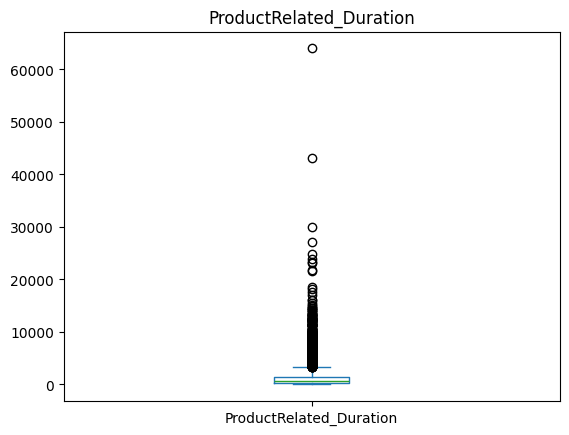

In [ ]:
import matplotlib.pyplot as plt

df["ProductRelated_Duration"].plot(kind="box")

plt.title("ProductRelated_Duration")
plt.show()

In [ ]:
q1 = df["ProductRelated_Duration"].quantile(0.25)
q3 = df["ProductRelated_Duration"].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[
    (df["ProductRelated_Duration"] < lower_bound) |
    (df["ProductRelated_Duration"] > upper_bound)
]

len(outliers)

961

по правилу IQR для `ProductRelated_Duration` получилось 961 потенциальное аномальное значение

удалять их не стал: большое время на товарных страницах вполне может быть реальным поведением пользователя, плюс для дерева такие значения сами по себе не являются проблемой

In [ ]:
df.duplicated().sum()

np.int64(125)

In [ ]:
df[df.duplicated(keep=False)].head(20)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
85,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,1,1,1,3,Returning_Visitor,False,False
132,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False
158,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,1,1,1,3,Returning_Visitor,False,False
159,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False
178,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False
252,0,0.0,0,0.0,2,0.0,0.2,0.2,0.0,0.0,Mar,1,1,1,1,Returning_Visitor,False,False
286,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,2,2,1,1,Returning_Visitor,False,False
293,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,1,1,1,1,Returning_Visitor,True,False
298,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,1,1,8,1,Returning_Visitor,False,False
330,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Mar,3,2,3,1,Returning_Visitor,False,False


In [ ]:
duplicates = df[df.duplicated(keep=False)]

duplicates.sort_values(
    by=list(df.columns)
).head(30)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
8247,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,1,Returning_Visitor,True,False
10751,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,1,Returning_Visitor,True,False
11658,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,1,Returning_Visitor,True,False
8882,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,2,New_Visitor,False,False
11934,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,2,New_Visitor,False,False
11110,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,3,Returning_Visitor,False,False
12159,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,1,3,Returning_Visitor,False,False
10341,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,4,1,Returning_Visitor,True,False
11801,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,4,1,Returning_Visitor,True,False
11938,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Dec,1,1,4,1,Returning_Visitor,True,False


`duplicated()` нашёл 125 полностью совпадающих строк

при этом отдельного id сессии в датасете нет, поэтому нельзя точно сказать, что это технические дубли, а не разные сессии с одинаковыми параметрами. поэтому эти строки оставляю

## 2. Исследовательский анализ данных

теперь смотрю, как отдельные признаки связаны с `Revenue`: сначала баланс классов, потом несколько категориальных и числовых признаков

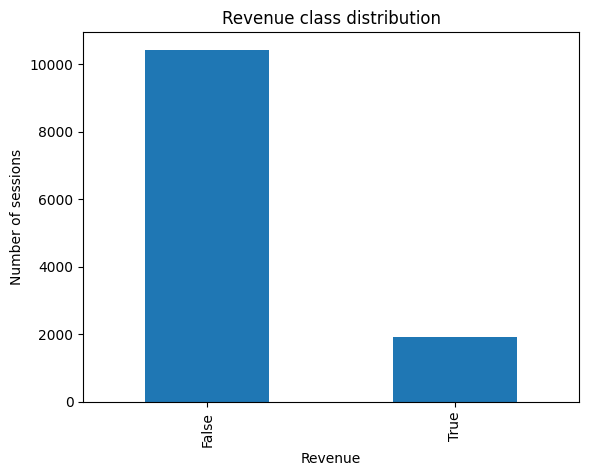

In [ ]:
df["Revenue"].value_counts().plot(kind="bar")

plt.title("Revenue class distribution")
plt.xlabel("Revenue")
plt.ylabel("Number of sessions")
plt.show()

по `Revenue` сразу видно сильный дисбаланс: примерно **84,5%** сессий заканчиваются без покупки и только **15,5%** покупкой

поэтому accuracy здесь сама по себе может быть обманчивой  - модель может почти всегда отвечать `False` и всё равно получить высокое значение. дальше смотрю еще precision, recall и F1

In [ ]:
pd.crosstab(
    df["VisitorType"],
    df["Revenue"],
    normalize="index"
) * 100

Revenue,False,True
VisitorType,,
New_Visitor,75.088548,24.911452
Other,81.176471,18.823529
Returning_Visitor,86.067671,13.932329


`VisitorType` выглядит полезным признаком: среди новых посетителей покупку совершают примерно **24,9%**, а среди возвращающихся около **13,9%**

In [ ]:
pd.crosstab(
    df["Month"],
    df["Revenue"],
    normalize="index"
) * 100

Revenue,False,True
Month,,
Aug,82.448037,17.551963
Dec,87.492762,12.507238
Feb,98.369565,1.630435
Jul,84.722222,15.277778
June,89.930556,10.069444
Mar,89.931830,10.068170
May,89.149822,10.850178
Nov,74.649767,25.350233
Oct,79.052823,20.947177


In [ ]:
month_stats = pd.DataFrame({
    "sessions": df["Month"].value_counts(),
    "purchase_rate_%": df.groupby("Month")["Revenue"].mean() * 100
})

month_stats.sort_values("purchase_rate_%", ascending=False)

,sessions,purchase_rate_%
Month,,
Nov,2998,25.350233
Oct,549,20.947177
Sep,448,19.196429
Aug,433,17.551963
Jul,432,15.277778
Dec,1727,12.507238
May,3364,10.850178
June,288,10.069444
Mar,1907,10.068170


по месяцам доля покупок тоже заметно отличается

например, в ноябре она около **25,35%**, а в мае около **10,85%**. при этом важно смотреть и на количество наблюдений: для февраля данных намного меньше, поэтому его процент менее показательный

In [ ]:
df.groupby("Revenue")["PageValues"].agg(["mean", "median"])

,mean,median
Revenue,,
False,1.975998,0.000000
True,27.264518,16.758134


`PageValues` очень сильно отличается между классами: для сессий без покупки медиана равна 0, а для сессий с покупкой около **16,76**

уже здесь видно, что этот признак может оказаться одним из самых сильных

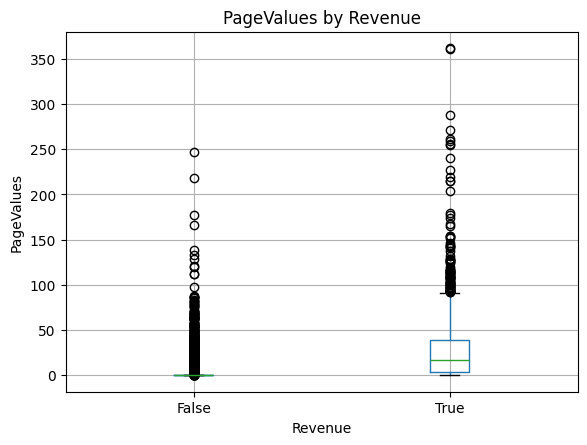

In [ ]:
df.boxplot(
    column="PageValues",
    by="Revenue"
)

plt.title("PageValues by Revenue")
plt.suptitle("")
plt.xlabel("Revenue")
plt.ylabel("PageValues")
plt.show()

на boxplot разница видна ещё лучше: у покупающих пользователей `PageValues` в целом выше

при этом распределения всё равно пересекаются, поэтому одного этого признака недостаточно, чтобы идеально разделить все сессии

In [ ]:
df.groupby("Revenue")[["BounceRates", "ExitRates"]].agg(["mean", "median"])

BounceRates           ExitRates          
               mean    median      mean    median
Revenue                                          
False      0.025317  0.004255  0.047378  0.028571
True       0.005117  0.000000  0.019555  0.016000

у сессий с покупкой `BounceRates` и `ExitRates` заметно ниже

то есть пользователи, которые меньше уходят со страницы и продолжают взаимодействовать с сайтом, чаще доходят до покупки

In [ ]:
df.groupby("Revenue")["ProductRelated"].agg(["mean", "median"])

,mean,median
Revenue,,
False,28.714642,16.0
True,48.210168,29.0


покупающие пользователи в среднем просматривают больше товарных страниц

медиана `ProductRelated` равна **29** для `Revenue=True` и **16** для `Revenue=False`, поэтому этот признак тоже выглядит полезным

## 3. Подготовка данных

отделяю признаки `X` от целевой переменной `y`, после этого делю данные на train / validation / test в соотношении 60 / 20 / 20

`train` нужен для обучения, `validation` для подбора параметров, а `test` оставляю на финальную проверку. при разбиении использую стратификацию, чтобы доля `True` и `False` везде осталась примерно одинаковой

In [ ]:
X = df.drop(columns=["Revenue"])
y = df["Revenue"]
print(X.shape)
print(y.shape)

(12330, 17)
(12330,)


In [ ]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(X_temp.shape)
print(X_test.shape)

(9864, 17)
(2466, 17)


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(7398, 17)
(2466, 17)
(2466, 17)


In [ ]:
print("Train:")
print(y_train.value_counts(normalize=True) * 100)

print("\nValidation:")
print(y_val.value_counts(normalize=True) * 100)

print("\nTest:")
print(y_test.value_counts(normalize=True) * 100)

Train:
Revenue
False    84.522844
True     15.477156
Name: proportion, dtype: float64

Validation:
Revenue
False    84.549878
True     15.450122
Name: proportion, dtype: float64

Test:
Revenue
False    84.509327
True     15.490673
Name: proportion, dtype: float64


стратификация сработала: доля положительного класса во всех трёх выборках осталась около 15,5%

значит разбиение не исказило исходный баланс классов

### Кодирование категориальных признаков

`Month`, `VisitorType`, `Browser`, `Region` и ещё несколько столбцов являются категориальными, для них использую One-Hot Encoding. числовые признаки оставляю как есть

нормализацию не применяю, потому что для дерева масштаб признаков не важен: оно строит пороговые разбиения, а не считает расстояния

In [ ]:
categorical_features = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend"
]

numeric_features = [
    column for column in X.columns
    if column not in categorical_features
]

print("Categorical:")
print(categorical_features)

print("\nNumeric:")
print(numeric_features)

Categorical:
['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']

Numeric:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numeric_features
        )
    ]
)

In [ ]:
X_train_prepared = preprocessor.fit_transform(X_train)

X_val_prepared = preprocessor.transform(X_val)
X_test_prepared = preprocessor.transform(X_test)

print(X_train_prepared.shape)
print(X_val_prepared.shape)
print(X_test_prepared.shape)

(7398, 74)
(2466, 74)
(2466, 74)


после One-Hot Encoding количество признаков выросло с 17 до 74

преобразователь обучаю только на `X_train` через `fit_transform`, а к validation и test применяю только `transform`, чтобы не подглядывать в отложенные данные

## 4. Baseline

перед основной моделью делаю простой ориентир - `DummyClassifier`, который всегда предсказывает самый частый класс. у нас это `Revenue=False`

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

baseline = DummyClassifier(strategy="most_frequent")

baseline.fit(X_train_prepared, y_train)

y_val_baseline = baseline.predict(X_val_prepared)

print("Accuracy:", accuracy_score(y_val, y_val_baseline))
print("Precision:", precision_score(y_val, y_val_baseline, zero_division=0))
print("Recall:", recall_score(y_val, y_val_baseline, zero_division=0))
print("F1:", f1_score(y_val, y_val_baseline, zero_division=0))

Accuracy: 0.8454987834549879
Precision: 0.0
Recall: 0.0
F1: 0.0


baseline получает accuracy около 84,5%, но precision, recall и F1 для класса `True` равны нулю

причина простая: модель вообще не ищет покупки и всегда отвечает `False`, поэтому дальше ориентироваться только на accuracy нельзя

## 5. Дерево решений из sklearn

сначала обучаю дерево вообще без ограничений, чтобы посмотреть, насколько сильно оно сможет подстроиться под train

In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    random_state=42
)

tree.fit(X_train_prepared, y_train)

y_train_pred = tree.predict(X_train_prepared)
y_val_pred = tree.predict(X_val_prepared)

print("Train:")
print("Accuracy:", accuracy_score(y_train, y_train_pred))
print("Precision:", precision_score(y_train, y_train_pred))
print("Recall:", recall_score(y_train, y_train_pred))
print("F1:", f1_score(y_train, y_train_pred))

print("\nValidation:")
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred))
print("Recall:", recall_score(y_val, y_val_pred))
print("F1:", f1_score(y_val, y_val_pred))

Train:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0

Validation:
Accuracy: 0.8657745336577454
Precision: 0.5618811881188119
Recall: 0.5958005249343832
F1: 0.578343949044586


неограниченное дерево идеально запомнило train - там все метрики равны 1

на validation F1 уже около 0,58, то есть видно явное переобучение. дальше ограничиваю сложность дерева

### Влияние глубины дерева

у дерева нет эпох обучения, поэтому качество смотрю при изменении его сложности: увеличиваю `max_depth` и сравниваю F1 на train и validation

In [ ]:
train_f1_scores = []
val_f1_scores = []
depths = range(1, 21)

for depth in depths:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train_prepared, y_train)

    train_pred = model.predict(X_train_prepared)
    val_pred = model.predict(X_val_prepared)

    train_f1_scores.append(f1_score(y_train, train_pred))
    val_f1_scores.append(f1_score(y_val, val_pred))

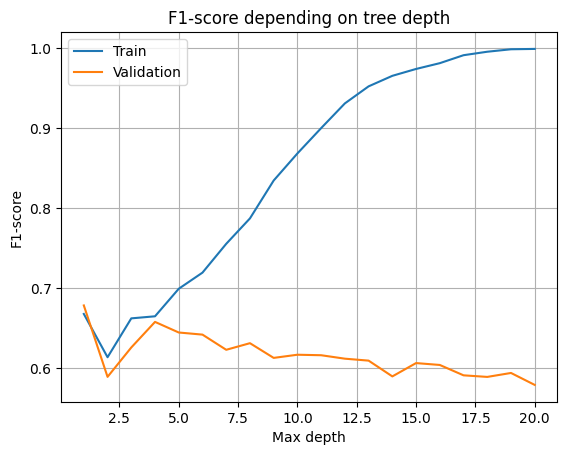

In [ ]:
plt.plot(depths, train_f1_scores, label="Train")
plt.plot(depths, val_f1_scores, label="Validation")

plt.xlabel("Max depth")
plt.ylabel("F1-score")
plt.title("F1-score depending on tree depth")
plt.legend()
plt.grid()

plt.show()

In [ ]:
best_val_f1 = max(val_f1_scores)
best_index = val_f1_scores.index(best_val_f1)
best_depth = list(depths)[best_index]

print("Best depth:", best_depth)
print("Best validation F1:", best_val_f1)
print("Train F1 at this depth:", train_f1_scores[best_index])

Best depth: 1
Best validation F1: 0.6780383795309168
Train F1 at this depth: 0.6674033149171271


лучший F1 на validation в этом переборе получился при `max_depth=1`

при увеличении глубины качество на train растёт, а validation в целом становится хуже - глубокое дерево начинает запоминать обучающие данные

### Подбор гиперпараметров

после отдельной проверки глубины перебираю сразу несколько параметров через `GridSearchCV`: `max_depth`, `min_samples_split` и `min_samples_leaf`

в качестве основной метрики беру F1, потому что классы у нас заметно несбалансированы

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [1, 2, 3, 4, 5, 6, 8, 10],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10, 20]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train_prepared, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV F1:", grid_search.best_score_)

Best parameters: {'max_depth': 1, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV F1: 0.6661407287200004


In [ ]:
best_tree = grid_search.best_estimator_

y_train_best = best_tree.predict(X_train_prepared)
y_val_best = best_tree.predict(X_val_prepared)

print("Train:")
print("Accuracy:", accuracy_score(y_train, y_train_best))
print("Precision:", precision_score(y_train, y_train_best))
print("Recall:", recall_score(y_train, y_train_best))
print("F1:", f1_score(y_train, y_train_best))

print("\nValidation:")
print("Accuracy:", accuracy_score(y_val, y_val_best))
print("Precision:", precision_score(y_val, y_val_best))
print("Recall:", recall_score(y_val, y_val_best))
print("F1:", f1_score(y_val, y_val_best))

Train:
Accuracy: 0.8779399837793999
Precision: 0.5770700636942675
Recall: 0.7912663755458516
F1: 0.6674033149171271

Validation:
Accuracy: 0.8775344687753447
Precision: 0.5709156193895871
Recall: 0.8346456692913385
F1: 0.6780383795309168


кросс-валидация снова выбрала очень простое дерево с `max_depth=1`

метрики train и validation у него близкие, поэтому сильного переобучения уже нет

### Какое разбиение выбрало дерево

для понимания модели вывожу структуру лучшего дерева и смотрю, какой признак и какой порог оно выбрало

In [ ]:
from sklearn.tree import export_text

feature_names = preprocessor.get_feature_names_out()

print(
    export_text(
        best_tree,
        feature_names=list(feature_names)
    )
)

|--- num__PageValues <= 1.12
|   |--- class: False
|--- num__PageValues >  1.12
|   |--- class: True



получилось одно разбиение: `PageValues <= 1.12`

это не значит, что я заранее оставил только один признак - при обучении дерево получило все признаки и само выбрало `PageValues` как лучшее первое разбиение. из-за `max_depth=1` других веток у него уже нет

### Дополнительная проверка влияния `PageValues`

после вывода структуры стало видно, что дерево глубины 1 использует только `PageValues`, поэтому отдельно проверяю вариант без него

этот блок не является финальной моделью, оставляю его просто как дополнительную проверку

In [ ]:
numeric_features_without_pagevalues = [
    column for column in numeric_features
    if column != "PageValues"
]

preprocessor_without_pagevalues = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numeric_features_without_pagevalues
        )
    ]
)

X_train_no_pagevalues = preprocessor_without_pagevalues.fit_transform(X_train)
X_val_no_pagevalues = preprocessor_without_pagevalues.transform(X_val)

In [ ]:
tree_no_pagevalues = DecisionTreeClassifier(
    max_depth=1,
    random_state=42
)

tree_no_pagevalues.fit(X_train_no_pagevalues, y_train)

y_val_no_pagevalues = tree_no_pagevalues.predict(X_val_no_pagevalues)

print("Accuracy:", accuracy_score(y_val, y_val_no_pagevalues))
print("Precision:", precision_score(y_val, y_val_no_pagevalues))
print("Recall:", recall_score(y_val, y_val_no_pagevalues))
print("F1:", f1_score(y_val, y_val_no_pagevalues))

Accuracy: 0.8454987834549879
Precision: 0.0
Recall: 0.0
F1: 0.0


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
grid_search_no_pagevalues = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid_search_no_pagevalues.fit(
    X_train_no_pagevalues,
    y_train
)

print("Best parameters:", grid_search_no_pagevalues.best_params_)
print("Best CV F1:", grid_search_no_pagevalues.best_score_)

Best parameters: {'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 20}
Best CV F1: 0.24895952294363596


без `PageValues` качество заметно падает: даже после подбора параметров F1 на кросс-валидации около 0,25

получается, что этот признак действительно очень информативный для нашей задачи. в финальной модели его оставляю

### Финальный подбор параметров sklearn-модели

дополнительно проверяю `criterion` и `class_weight`, чтобы убедиться, что более сложные варианты не дают лучший F1

In [ ]:
param_grid_final = {
    "criterion": ["gini", "entropy"],
    "max_depth": [1, 2, 3, 4, 5, 6],
    "min_samples_leaf": [1, 5, 10, 20],
    "class_weight": [None, "balanced"]
}

final_grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_final,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

final_grid_search.fit(X_train_prepared, y_train)

print("Best parameters:", final_grid_search.best_params_)
print("Best CV F1:", final_grid_search.best_score_)

Best parameters: {'class_weight': None, 'criterion': 'gini', 'max_depth': 1, 'min_samples_leaf': 1}
Best CV F1: 0.6661407287200004


расширенный поиск снова выбрал `gini`, `max_depth=1` и вариант без балансировки классов

то есть `entropy` и `class_weight="balanced"` в моём случае улучшения не дали

### Проверка на test

после выбора параметров один раз проверяю итоговую модель на test. по этой выборке уже ничего не подбираю, она нужна только для финальной проверки

In [ ]:
final_tree = final_grid_search.best_estimator_

y_test_pred = final_tree.predict(X_test_prepared)

print("Test:")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print(
    "Precision:",
    precision_score(y_test, y_test_pred, zero_division=0)
)
print(
    "Recall:",
    recall_score(y_test, y_test_pred, zero_division=0)
)
print(
    "F1:",
    f1_score(y_test, y_test_pred, zero_division=0)
)

Test:
Accuracy: 0.8686131386861314
Precision: 0.5551330798479087
Recall: 0.7643979057591623
F1: 0.6431718061674009


In [ ]:
results = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test"],
    "Accuracy": [
        accuracy_score(y_train, y_train_best),
        accuracy_score(y_val, y_val_best),
        accuracy_score(y_test, y_test_pred)
    ],
    "Precision": [
        precision_score(y_train, y_train_best),
        precision_score(y_val, y_val_best),
        precision_score(y_test, y_test_pred)
    ],
    "Recall": [
        recall_score(y_train, y_train_best),
        recall_score(y_val, y_val_best),
        recall_score(y_test, y_test_pred)
    ],
    "F1": [
        f1_score(y_train, y_train_best),
        f1_score(y_val, y_val_best),
        f1_score(y_test, y_test_pred)
    ]
})

results

,Dataset,Accuracy,Precision,Recall,F1
0,Train,0.877940,0.577070,0.791266,0.667403
1,Validation,0.877534,0.570916,0.834646,0.678038
2,Test,0.868613,0.555133,0.764398,0.643172


результаты на train, validation и test получились достаточно близкими

F1 на test около 0,64, большого разрыва между выборками нет, значит после ограничения глубины переобучение стало намного меньше

### Confusion matrix

отдельно смотрю матрицу ошибок, чтобы было видно не только итоговые метрики, но и сколько покупок модель нашла, сколько пропустила и где ошиблась

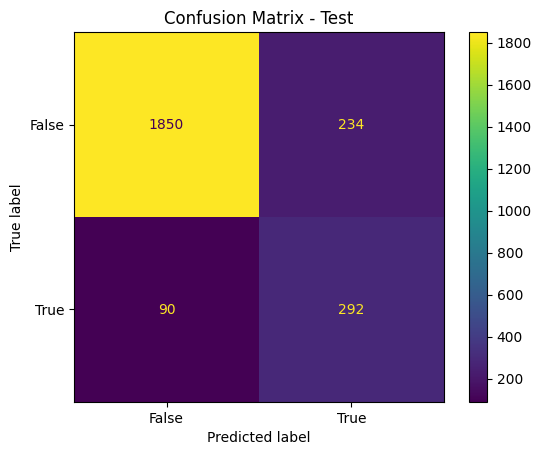

In [113]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[False, True]
)

disp.plot()
plt.title("Confusion Matrix - Test")
plt.show()

на test модель правильно определила **1850** сессий без покупки и **292** сессии с покупкой

при этом **90** реальных покупок были пропущены, а в **234** случаях модель предсказала покупку ошибочно. отсюда recall около **76,4%**, precision около **55,5%**

## 6. Собственная реализация дерева решений

теперь реализую этот же алгоритм сам. использую критерий Gini и два гиперпараметра: `max_depth` и `min_samples_split`

реализацию делаю по частям: Gini, оценка разбиения, поиск лучшего признака и порога, рекурсивное построение дерева и `predict`. маленькие тесты на искусственных данных тоже оставляю, чтобы было видно, что каждая часть отдельно работает

### 6.1. Критерий Gini

In [ ]:
import numpy as np

def gini(y):
    classes, counts = np.unique(y, return_counts=True)
    probabilities = counts / len(y)

    return 1 - np.sum(probabilities ** 2)

print(gini(np.array([False, False, False, False])))
print(gini(np.array([False, False, True, True])))
print(gini(np.array([False, False, False, True])))

0.0
0.5
0.375


проверка функции даёт ожидаемые значения: Gini равен 0 для полностью чистого узла, 0,5 для равного смешения двух классов и 0,375 для соотношения 3 к 1

### 6.2. Оценка качества разбиения

для двух получившихся веток считаю взвешенный Gini, чем он меньше, тем лучше разделены классы

In [ ]:
def split_gini(y_left, y_right):
    n = len(y_left) + len(y_right)

    left_weight = len(y_left) / n
    right_weight = len(y_right) / n

    return (
        left_weight * gini(y_left)
        + right_weight * gini(y_right)
    )
y_left = np.array([False, False, False])
y_right = np.array([True, True])

print(split_gini(y_left, y_right))

y_left = np.array([False, True])
y_right = np.array([False, True])

print(split_gini(y_left, y_right))

0.0
0.5


### 6.3. Поиск лучшего признака и порога

перебираю признаки и возможные границы разбиения, потом выбираю вариант с минимальным взвешенным Gini. для проверки беру простой пример, где классы можно разделить идеально

In [ ]:
def find_best_split(X, y):
    best_gini = float("inf")
    best_feature = None
    best_threshold = None

    y = np.asarray(y).astype(int)
    n_samples, n_features = X.shape

    for feature_index in range(n_features):
        feature_values = X[:, feature_index]

        order = np.argsort(feature_values)

        x_sorted = feature_values[order]
        y_sorted = y[order]

        # Разделять имеет смысл только между различными значениями
        split_positions = np.where(
            x_sorted[:-1] != x_sorted[1:]
        )[0]

        if len(split_positions) == 0:
            continue

        cumulative_positive = np.cumsum(y_sorted)
        total_positive = cumulative_positive[-1]

        left_count = split_positions + 1
        right_count = n_samples - left_count

        left_positive = cumulative_positive[split_positions]
        right_positive = total_positive - left_positive

        left_negative = left_count - left_positive
        right_negative = right_count - right_positive

        left_gini = 1 - (
            (left_positive / left_count) ** 2
            + (left_negative / left_count) ** 2
        )

        right_gini = 1 - (
            (right_positive / right_count) ** 2
            + (right_negative / right_count) ** 2
        )

        weighted_gini = (
            left_count * left_gini
            + right_count * right_gini
        ) / n_samples

        best_position_index = np.argmin(weighted_gini)
        current_gini = weighted_gini[best_position_index]

        if current_gini < best_gini:
            position = split_positions[best_position_index]

            best_gini = current_gini
            best_feature = feature_index

            best_threshold = (
                x_sorted[position]
                + x_sorted[position + 1]
            ) / 2

    return best_feature, best_threshold, best_gini

X_example = np.array([
    [1],
    [2],
    [3],
    [8],
    [9],
    [10]
])

y_example = np.array([
    False,
    False,
    False,
    True,
    True,
    True
])

feature, threshold, score = find_best_split(
    X_example,
    y_example
)

print("Feature:", feature)
print("Threshold:", threshold)
print("Gini:", score)

Feature: 0
Threshold: 5.5
Gini: 0.0


### 6.4. Узел и класс дерева

в узле храню индекс признака, порог и ссылки на две ветки. в листе вместо разбиения хранится итоговый класс

In [ ]:
class Node:
    def __init__(
        self,
        feature_index=None,
        threshold=None,
        left=None,
        right=None,
        value=None
    ):
        self.feature_index = feature_index
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

In [ ]:
class MyDecisionTreeClassifier:
    def __init__(self, max_depth=5, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)

        self.root = self._build_tree(X, y, depth=0)

        return self

    def _build_tree(self, X, y, depth):
        if len(np.unique(y)) == 1:
            return Node(value=y[0])

        if depth >= self.max_depth:
            return Node(value=self._most_common_class(y))

        if len(y) < self.min_samples_split:
            return Node(value=self._most_common_class(y))

        feature_index, threshold, best_gini = find_best_split(X, y)

        if feature_index is None:
            return Node(value=self._most_common_class(y))

        if best_gini >= gini(y):
            return Node(value=self._most_common_class(y))

        left_mask = X[:, feature_index] <= threshold
        right_mask = X[:, feature_index] > threshold

        left_child = self._build_tree(
            X[left_mask],
            y[left_mask],
            depth + 1
        )

        right_child = self._build_tree(
            X[right_mask],
            y[right_mask],
            depth + 1
        )

        return Node(
            feature_index=feature_index,
            threshold=threshold,
            left=left_child,
            right=right_child
        )

    def _most_common_class(self, y):
        classes, counts = np.unique(y, return_counts=True)
        return classes[np.argmax(counts)]

    def predict(self, X):
        X = np.asarray(X)

        predictions = [
            self._predict_one(row, self.root)
            for row in X
        ]

        return np.array(predictions)

    def _predict_one(self, row, node):
        if node.value is not None:
            return node.value

        if row[node.feature_index] <= node.threshold:
            return self._predict_one(row, node.left)
        else:
            return self._predict_one(row, node.right)

### 6.5. Проверка на простом примере

перед запуском на основном датасете проверяю `fit` и `predict` на маленьком наборе, где правильный ответ заранее понятен

In [ ]:
my_tree_example = MyDecisionTreeClassifier(
    max_depth=3,
    min_samples_split=2
)

my_tree_example.fit(X_example, y_example)

In [ ]:
predictions = my_tree_example.predict(X_example)

print("Predictions:", predictions)
print("True values:", y_example)

Predictions: [False False False  True  True  True]
True values: [False False False  True  True  True]


на тестовом примере предсказания полностью совпали с правильными ответами, значит можно переходить к основным данным

### 6.6. Обучение собственной модели на основном датасете

использую те же подготовленные данные, что и для sklearn-модели, чтобы сравнение было честным

In [ ]:
my_tree = MyDecisionTreeClassifier(
    max_depth=1,
    min_samples_split=2
)

my_tree.fit(
    X_train_prepared,
    y_train
)

In [ ]:
my_train_pred = my_tree.predict(X_train_prepared)
my_val_pred = my_tree.predict(X_val_prepared)
my_test_pred = my_tree.predict(X_test_prepared)

print("Train:")
print("Accuracy:", accuracy_score(y_train, my_train_pred))
print("Precision:", precision_score(y_train, my_train_pred, zero_division=0))
print("Recall:", recall_score(y_train, my_train_pred, zero_division=0))
print("F1:", f1_score(y_train, my_train_pred, zero_division=0))

print("\nValidation:")
print("Accuracy:", accuracy_score(y_val, my_val_pred))
print("Precision:", precision_score(y_val, my_val_pred, zero_division=0))
print("Recall:", recall_score(y_val, my_val_pred, zero_division=0))
print("F1:", f1_score(y_val, my_val_pred, zero_division=0))

print("\nTest:")
print("Accuracy:", accuracy_score(y_test, my_test_pred))
print("Precision:", precision_score(y_test, my_test_pred, zero_division=0))
print("Recall:", recall_score(y_test, my_test_pred, zero_division=0))
print("F1:", f1_score(y_test, my_test_pred, zero_division=0))

Train:
Accuracy: 0.8779399837793999
Precision: 0.5770700636942675
Recall: 0.7912663755458516
F1: 0.6674033149171271

Validation:
Accuracy: 0.8775344687753447
Precision: 0.5709156193895871
Recall: 0.8346456692913385
F1: 0.6780383795309168

Test:
Accuracy: 0.8686131386861314
Precision: 0.5551330798479087
Recall: 0.7643979057591623
F1: 0.6431718061674009


на основном датасете собственное дерево при `max_depth=1` даёт те же метрики, что и sklearn-модель

получается, что логика выбора разбиения и предсказания реализована правильно

### 6.7. Подбор гиперпараметров собственной модели

для своей реализации вручную перебираю два гиперпараметра - `max_depth` и `min_samples_split`, лучший вариант выбираю по F1 на validation

In [ ]:
depth_values = [1, 2, 3, 4]
split_values = [2, 5, 10, 20]

best_my_f1 = -1
best_my_depth = None
best_my_split = None

for depth in depth_values:
    for min_split in split_values:
        model = MyDecisionTreeClassifier(
            max_depth=depth,
            min_samples_split=min_split
        )

        model.fit(X_train_prepared, y_train)

        val_pred = model.predict(X_val_prepared)
        current_f1 = f1_score(y_val, val_pred)

        print(
            f"max_depth={depth}, "
            f"min_samples_split={min_split}, "
            f"F1={current_f1:.4f}"
        )

        if current_f1 > best_my_f1:
            best_my_f1 = current_f1
            best_my_depth = depth
            best_my_split = min_split

print("\nBest parameters:")
print("max_depth:", best_my_depth)
print("min_samples_split:", best_my_split)
print("Validation F1:", best_my_f1)

max_depth=1, min_samples_split=2, F1=0.6780
max_depth=1, min_samples_split=5, F1=0.6780
max_depth=1, min_samples_split=10, F1=0.6780
max_depth=1, min_samples_split=20, F1=0.6780
max_depth=2, min_samples_split=2, F1=0.5888
max_depth=2, min_samples_split=5, F1=0.5888
max_depth=2, min_samples_split=10, F1=0.5888
max_depth=2, min_samples_split=20, F1=0.5888
max_depth=3, min_samples_split=2, F1=0.6255
max_depth=3, min_samples_split=5, F1=0.6255
max_depth=3, min_samples_split=10, F1=0.6255
max_depth=3, min_samples_split=20, F1=0.6255
max_depth=4, min_samples_split=2, F1=0.6575
max_depth=4, min_samples_split=5, F1=0.6575
max_depth=4, min_samples_split=10, F1=0.6575
max_depth=4, min_samples_split=20, F1=0.6575

Best parameters:
max_depth: 1
min_samples_split: 2
Validation F1: 0.6780383795309168


лучшим снова оказался `max_depth=1`

при такой глубине разные значения `min_samples_split` из проверенного диапазона дают один и тот же результат, потому что объектов в корневом узле намного больше этих ограничений. код сохраняет первое лучшее значение - `min_samples_split=2`

## 7. Сравнение моделей

в конце сравниваю baseline, `DecisionTreeClassifier` из sklearn и свою реализацию на одной и той же тестовой выборке

In [ ]:
# Baseline на test
y_test_baseline = baseline.predict(X_test_prepared)

# Финальная собственная модель
my_final_tree = MyDecisionTreeClassifier(
    max_depth=best_my_depth,
    min_samples_split=best_my_split
)

my_final_tree.fit(X_train_prepared, y_train)

my_test_final_pred = my_final_tree.predict(X_test_prepared)

comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Sklearn Decision Tree",
        "My Decision Tree"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_test_baseline),
        accuracy_score(y_test, y_test_pred),
        accuracy_score(y_test, my_test_final_pred)
    ],

    "Precision": [
        precision_score(y_test, y_test_baseline, zero_division=0),
        precision_score(y_test, y_test_pred, zero_division=0),
        precision_score(y_test, my_test_final_pred, zero_division=0)
    ],

    "Recall": [
        recall_score(y_test, y_test_baseline, zero_division=0),
        recall_score(y_test, y_test_pred, zero_division=0),
        recall_score(y_test, my_test_final_pred, zero_division=0)
    ],

    "F1": [
        f1_score(y_test, y_test_baseline, zero_division=0),
        f1_score(y_test, y_test_pred, zero_division=0),
        f1_score(y_test, my_test_final_pred, zero_division=0)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1
0,Baseline,0.845093,0.000000,0.000000,0.000000
1,Sklearn Decision Tree,0.868613,0.555133,0.764398,0.643172
2,My Decision Tree,0.868613,0.555133,0.764398,0.643172


по итоговой таблице видно, что baseline имеет F1=0, а sklearn и моё дерево дают одинаковые метрики на test

то есть для выбранных параметров собственная реализация повторяет результат библиотечной модели

## 8. Итоговый вывод

в этой работе я разобрал датасет **Online Shoppers Purchasing Intention** и решал задачу бинарной классификации - будет покупка или нет

сначала сделал baseline, который всегда выбирал самый частый класс. accuracy у него получилась высокой, около **84,5%**, но F1 для покупок оказался равен нулю - на этом хорошо видно, почему на несбалансированных данных одной accuracy мало

неограниченное дерево сильно переобучалось: на train метрики доходили до 1. после ограничения глубины и подбора параметров лучшим оказался простой вариант с `max_depth=1`

на test он показал примерно **0,869 accuracy**, **0,555 precision**, **0,764 recall** и **0,643 F1**

отдельно проверил влияние `PageValues`: итоговое дерево действительно делает первое разбиение именно по этому признаку, а без него качество заметно падает. при этом я не выбирал `PageValues` вручную, модель получила весь набор признаков и сама выбрала лучшее разбиение

после sklearn-модели реализовал дерево самостоятельно: расчёт Gini, поиск лучшего признака и порога, рекурсивное построение узлов и `predict`. в своей модели использовал два гиперпараметра - `max_depth` и `min_samples_split` - и отдельно перебрал их значения

на тестовой выборке моя реализация получила те же метрики, что и `DecisionTreeClassifier` из sklearn. для этой конфигурации обе модели пришли к одному и тому же разбиению, поэтому результат совпал